# (3) Example_MNIST_CNN_InMemoryComputing

Questo notebook contiene un esempio su come valutare l'impatto in accuratezza nell'eseguire con In-Memory Computing una Convolutional Neural Network (CNN) giá allenarla.

Tra i tanti simulatori possibili, questo notebbok utilizza il framework [**Cross-Sim**](https://github.com/sandialabs/cross-sim). Il codice sorgente di **Cross-Sim** é que incluso per semplicitá nelle cartelle `./applications` e `./simulator`. Per eseguire questo notebook non é richiesta alcuna conoscenza del framework. Nel caso si voglia approfondire le funzionalitá di **Cross-Sim** si consiglia di fare riferimento al _git_ specifico del simulatore ed alla sua documentazione.

## 1. Setup and Imports

Importiamo le librarie che ci serviranno

In [1]:

import numpy as np
from applications.mvm_params import set_params
from simulator.devices import idevice
import matplotlib.pyplot as plt
from simulator.algorithms.dnn.torch.convert import from_torch, reinitialize, synchronize
import torch
from torchvision import datasets, transforms
from tqdm import tqdm

np.random.seed(42)

## 2. Data Preparation

Come per l'allenamento, é necessario avere accesso al dataset (e.g. MNIST) per fornirlo in ingresso alla rete.

In [2]:
# Inference batch size
batch_size = 64

# Load the MNIST training set
mnist_data = datasets.MNIST("./", download=True, train=True,
                              transform=transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))  
                                ]),
                              target_transform=transforms.Compose([
                                lambda x:torch.tensor([x]), 
                                lambda x:torch.nn.functional.one_hot(x,10).float(),
                                lambda x:x.squeeze(),
                                ]))

# Load the MNIST test set
mnist_test = datasets.MNIST("./", download=True, train=False,
                              transform=transforms.Compose([
                                transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))  
                                ]),
                              target_transform=transforms.Compose([
                                lambda x:torch.tensor([x]), 
                                lambda x:torch.nn.functional.one_hot(x,10).float(),
                                lambda x:x.squeeze(),
                                ]))

# Split dataset into training and validation and create data loaders
ds_train, ds_val = torch.utils.data.random_split(mnist_data, [0.8, 0.2])
mnist_loader_train = torch.utils.data.DataLoader(ds_train, batch_size=batch_size, shuffle=True)
mnist_loader_val = torch.utils.data.DataLoader(ds_val, batch_size=batch_size, shuffle=False)

# Create test set loader
mnist_loader_test = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
N_test = len(mnist_loader_test.dataset)

## 3. Define the CNN Model

Se abbiamo una rete giá allenata, quello che é stato salvato sono i valori di tutte le variabili interne alla rete. Dobbiamo comunque definire nel nostro nuovo script o notebook la struttura della rete in modo che quando le variabili vengono caricate il compilatore Python sappia dove a cosa corrisponde ogni variabile. Nel seguito quindi la stessa ddefinizione di rete CNN che abbiamo usato nel training.

In [3]:
# Define the CNN topology
def mnist_cnn():
    return torch.nn.Sequential(
        torch.nn.Conv2d(1, 8, 3, padding='valid', stride=2),
        torch.nn.ReLU(),
        torch.nn.Conv2d(8, 16, 3, padding='valid', stride=2),
        torch.nn.ReLU(),
        torch.nn.Flatten(),
        torch.nn.Linear(576, 16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 10)
        )

## 4. Training and Testing Functions

Anche se non ci serve piú esplicitamente per il training, il Wrapper che avevamo definito coniente anche un'interfaccia per il testing. É quindi conveniente e coerente ri-definirlo.
Ribadiamo che la definizione di una funzione Wrapper, per quanto non rara, non é di per sé uno standard nell'allenamento di reti in Pytorch. Resta comunque vantaggioso per poter poi utilizzare il framework Cross-Sim per In-Memory Computing.

In [4]:
# Wrapper for training the CNN
class SequentialWrapper():
    def __init__(self, net, loss, learning_rate=1e-3):
        self.net = net
        self.loss = loss
        self.learning_rate = learning_rate
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=self.learning_rate)

    def forward(self, x):
        return self.net(x)
    
    def training_step(self, batch):
        self.optimizer.zero_grad()
        pred = self.forward(batch[0])
        loss = self.loss(pred, batch[1])
        loss.backward()
        self.optimizer.step()
        return loss

    def validation_step(self, batch):
        pred = self.forward(batch[0])
        loss = self.loss(pred, batch[1])
        return loss
    
    def train_epoch(self, train_loader, val_loader):
        loss_train, loss_val = 0, 0
        for minibatch in iter(train_loader):
            loss_train += self.training_step(minibatch).detach()
        for minibatch in iter(val_loader):
            loss_val += self.validation_step(minibatch).detach()
        return loss_train/len(train_loader), loss_val/len(val_loader)
    
    def train(self, train_loader, val_loader, epochs):
        loss_train, loss_val = np.zeros(epochs), np.zeros(epochs)
        for e in tqdm(range(0, epochs)):
            lt, lv = self.train_epoch(train_loader, val_loader)
            loss_train[e] = lt
            loss_val[e] = lv
        return loss_train, loss_val

# Create the wrapped PyTorch model
mnist_cnn_pt = SequentialWrapper(mnist_cnn(), torch.nn.CrossEntropyLoss())

## 5. Load Trained Network

Una volta ri-definita la struttura della rete uguale a quella che é stata allenata, possiamo leggere le variabili ottenute alla fine del _training_.


In [5]:
mnist_cnn_pt.net.load_state_dict(torch.load('trained_mnist_cnn.pt'))


<All keys matched successfully>

Testiamo con un'_inferenza_ che le variabili siano state caricate correttamente.
Poiché stiamo usando lo stesso subset dei dati (_testing_) ci aspettiamo la stessa accuratezza ottenuta alla fine del notebook `Example_MNIST_CNN_Train`.

In [6]:

# Perform inference on the test set, with no analog errors
y_pred, y, k = np.zeros(N_test), np.zeros(N_test), 0
for inputs, labels in mnist_loader_test:
    with torch.no_grad():
        output = mnist_cnn_pt.net(inputs)
        y_pred_k = output.data.detach().numpy()
        y_pred = np.append(y_pred,y_pred_k.argmax(axis=-1))
        y = np.append(y,labels.detach().numpy().argmax(axis=1))

# Evaluate accuracy
accuracy_digitalTrain_digitalTest = np.sum(y == y_pred)/len(y)
print('===========')
print('No analog errors during training, no analog errors during test')
print('Test accuracy: {:.2f}%\n'.format(accuracy_digitalTrain_digitalTest*100))

No analog errors during training, no analog errors during test
Test accuracy: 98.88%



## 6. In-Memory Computing Settings

Eseguire una rete neural su hardware che consente In-Memory Computing (IMC) é piú efficiente in termini di consumi di potenza rispetto a CPU o GPU. Allo stesso tempo peró si ha il trade-off di non avere piú una computazione "esatta" digitale ma di averne un'approssimazione analogica. Per valutare quando degrada l'accuratezza della rete con IMC, bisogna ricorrere a framework dedicati come **Cross-Sim**. 

Nelle celle seguenti vengono definiti i parametri che mi descrivono il sistema IMC e che sono necessari a **Cross-Sim** per valutare l'impatto sull'accuratezza. In particolare viene descritto, il modello della Resistive Random Access Memory (RRAM), il numero di bits usati per ogni peso della rete (_quantizzazione_) e come avviele la mappatura peso <-> RRAM. Per maggiori dettagli su queste impostazioni fare riferimento alla documentazione su [git-repo](https://github.com/sandialabs/cross-sim) ufficiale di **Cross-Sim**.

In [7]:
class measured_RRAM(idevice.EmptyDevice):
    """    This class implements a device that simulates the behavior of the measured RRAM during the lab experience.
    It is used to model the programming errors that were observed in the lab.

    """

    #### Programming error model
    def programming_error(self, Gnorm):
        """    This function applies the programming errors to Gnorm. Gnorm is the matrix of normalized conductances, where each element is in the range [0, 1]. usati
        """

        # Convert the normalized conductance matrix into Siemens
        Gmax = 1/self.device_params.Rmin # (e.g. Rmin=5kOhm, Gmax=200uS)
        Gmin = 1/self.device_params.Rmax # (e.g. Rmax=50kOhm, Gmin=20uS)

        # G is the matrix of conductances in uS
        G = ( Gmin + (Gmax - Gmin) * (Gnorm - self.Gmin_norm) / self.Grange_norm ) * 1e6
        
        # TODO: Modify with measured sigma ( constant for all conductances)
        sigma_G = np.full(G.shape, 13) # uS

        G += np.random.normal(loc=0.0, scale=sigma_G, size=G.shape)
        
        # Scale the conductance back down to normalized conductance units
        Gnorm = G * 1e-6 / Gmax
        return Gnorm

In [8]:
# Setting for CrossSim simulated hardware
params_imc = set_params(
    wtmodel = "BALANCED", 
    weight_bits = 8, # 8 bits  (1 bit for sign) <---- Puó essere modificato per indicare
    # NOTE: cell_bits = np.ceil((weight_bits-1) / Nslices)
        # Hence, you set Nslices accordingly to the cell_bits you want!
    Nslices = 2, # <---- Puó essere modificato per indicare
    Rmin = 2.932e3,
    Rmax = 83.631e3,
    error_model = "measured_RRAM")

## 7. In-Memory Computing Testing

Una volta selezionato come il nostro sistema IMC verrá realizzato, possiamo convertire la rete da puro Python alla sua versione mappata sul framework **Cross-Sim** e lanciare una _inferenza_ per testare come l'accuratezza é stata degradata.

Il simulare errori in accuratezza provenienti dall'IMC ha un costo computazione significatico, per cui l'_inferenza_ viene fatta solamente su ridotto numero di immagini dal subset _testing_.

In [9]:

# Convert the layers in the trained CNN
imc_mnist_cnn_pt = from_torch(mnist_cnn_pt.net, params_imc)

# Number of inference simulations with re-sampled random analog errors
N_runs = 10

# Perform analog inference on the test set
accuracies = np.zeros(N_runs)
for i in range(N_runs):
    print("Inference simulation {:d} of {:d}".format(i+1,N_runs), end="\r")
    y_pred, y, k = np.zeros(N_test), np.zeros(N_test), 0
    for inputs, labels in mnist_loader_test:
        with torch.no_grad():
            output = imc_mnist_cnn_pt.forward(inputs)
            y_pred_k = output.data.detach().numpy()
            y_pred = np.append(y_pred,y_pred_k.argmax(axis=-1))
            y = np.append(y,labels.detach().numpy().argmax(axis=1))
    accuracies[i] = np.sum(y == y_pred)/len(y)
    reinitialize(imc_mnist_cnn_pt)

# Evaluate average test accuracy
print('\n===========')
print('No analog errors during training, CrossSim analog errors during test')
accuracy_digitalTrain_analogTest = np.mean(accuracies)
std_digitalTrain_analogTest = np.std(accuracies)
print('Test accuracy: {:.2f}% +/- {:.3f}%'.format(100*accuracy_digitalTrain_analogTest,100*std_digitalTrain_analogTest))

Inference simulation 10 of 10
No analog errors during training, CrossSim analog errors during test
Test accuracy: 88.96% +/- 2.457%


## 8. Hardware-Aware Training

Per recuperare l'accuratezza persa per via della mappatura su In-Memory Computing, si puó ri-allenare la rete in modo che impari ad adattarsi alle non-idealitá hardware.

Per far questo definiamo una funzione Wrapper per il training specifica per **Cross-Sim** che eredita il Wrapper che abbiamo giá definito e lo modifica. L'unica reale modifica rispetto al Wrapper **PyTorch** é il metodo `synchronize` che viene chiamato dopo il `backward pass` nel training per aggiornare i valori delle resistenze nelle crossbar che emulano la computazione IMC.

In [10]:
# Modified training warpper for CrossSim-in-the-loop training
class SequentialWrapper_CrossSim(SequentialWrapper):
    def __init__(self, net, loss, learning_rate=1e-3):
        super().__init__(net, loss, learning_rate)
        
    def training_step(self, batch):
        self.optimizer.zero_grad()
        pred = self.forward(batch[0])
        loss = self.loss(pred, batch[1])
        loss.backward()
        self.optimizer.step()
        synchronize(self.net)  # <--- The only changed line in all of training!
        return loss


Definiamo una nuova CNN su cui carichiamo la rete giá allenata, che mapperemo su IMC, e che modificheremo con un nuovo training. Non riutilizziamo la struttura sopra in modo da poter fare il confronto prima e dopo il training.

In [11]:

# Create a PyTorch model with CrossSim-compatible layers
imc_mnist_cnn = from_torch(mnist_cnn(), params_imc)

# Create the wrapped analog PyTorch model
imc_mnist_cnn_CS = SequentialWrapper_CrossSim(imc_mnist_cnn, torch.nn.CrossEntropyLoss())

# Number of training epochs
N_epochs = 20

# Train the analog PyTorch model
loss_train_CS, loss_val_CS = imc_mnist_cnn_CS.train(mnist_loader_train, mnist_loader_val, N_epochs)

100%|██████████| 20/20 [51:39<00:00, 154.99s/it]


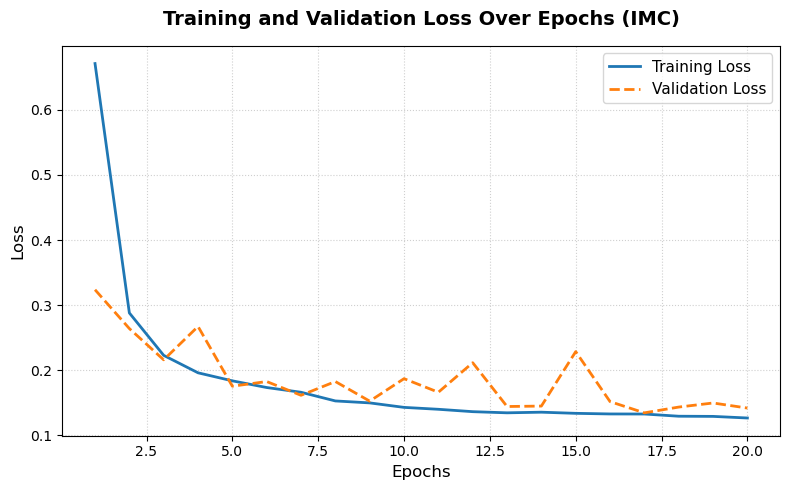

In [12]:
x_axis_epochs = np.arange(1, len(loss_train_CS) + 1)

# Initialize the plot layout
plt.figure(figsize=(8, 5))

# Plot both curves
plt.plot(x_axis_epochs, loss_train_CS, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(x_axis_epochs, loss_val_CS, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')

# Add descriptive elements
plt.title('Training and Validation Loss Over Epochs (IMC)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Display the chart
plt.tight_layout()
# plt.show()
plt.savefig('train_val_loss_imc.png', bbox_inches='tight', dpi=200)

Finally, let's perform inference simulation with conductance errors to see if our model that had hardware-aware training (with the same conductance errors as inference) achieves higher accuracy than the model with standard training.

In [13]:
# Perform analog inference on the test set
accuracies = np.zeros(N_runs)
for i in range(N_runs):
    print("Inference simulation {:d} of {:d}".format(i+1,N_runs), end="\r")
    y_pred, y, k = np.zeros(N_test), np.zeros(N_test), 0
    for inputs, labels in mnist_loader_test:
        with torch.no_grad():
            new_input = inputs[0:1]
            output = imc_mnist_cnn_CS.net(inputs)
            # output = imc_mnist_cnn_CS.net(new_input)
            y_pred_k = output.data.detach().numpy()
            y_pred = np.append(y_pred,y_pred_k.argmax(axis=-1))
            y = np.append(y,labels.detach().numpy().argmax(axis=1))
    accuracies[i] = np.sum(y == y_pred)/len(y)
    reinitialize(imc_mnist_cnn_CS.net)

# Evaluate average test accuracy
print('\n===========')
print('CrossSim analog errors during training, CrossSim analog errors during test')
accuracy_analogTrain_analogTest = np.mean(accuracies)
std_analogTrain_analogTest = np.std(accuracies)
print('Test accuracy: {:.2f}% +/- {:.3f}%'.format(accuracy_analogTrain_analogTest*100,std_analogTrain_analogTest*100))

Inference simulation 10 of 10
CrossSim analog errors during training, CrossSim analog errors during test
Test accuracy: 98.10% +/- 0.188%


In [14]:
# Save the model
torch.save(imc_mnist_cnn_CS.net.state_dict(), "trained_mnist_cnn_imc.pt")

## 8. Summary Table

In [15]:
print("Accuracy on MNIST test set")
print("================")
print("Standard training, standard inference: {:.2f}%".format(100*accuracy_digitalTrain_digitalTest))
print("Standard training, CrossSim inference: {:.2f}% +/- {:.3f}%".format(100*accuracy_digitalTrain_analogTest, 100*std_digitalTrain_analogTest))
print("CrossSim training, CrossSim inference: {:.2f}% +/- {:.3f}%".format(100*accuracy_analogTrain_analogTest, 100*std_analogTrain_analogTest))

Accuracy on MNIST test set
Standard training, standard inference: 98.88%
Standard training, CrossSim inference: 88.96% +/- 2.457%
CrossSim training, CrossSim inference: 98.10% +/- 0.188%
